








## 7. Code walkthrough video
- Produce a video (up to 3 minutes in length) where you present a code walkthrough.
- Ensure that you are visible in the video. You can use Zoom or similar software to record this.
- **[2 marks]**


# Task 1

## Read and preprocess tweet data
- Read the important features of Kamala Harris' and Donald Trump's tweets into a single Pandas DataFrame. 
- The "important features" refer to those necessary for subsequent tasks.
- **[1 mark]**

In [30]:
#importing the necessary libraries
import pandas as pd
import json
import matplotlib.pyplot as plt
from IPython.display import display, HTML


# Load Donald Trump's tweets
with open('/workspaces/AppDSTask2/donald-200-tweets.txt') as file:
    trump_tweets = json.load(file)

# Load Kamala Harris' tweets
with open('/workspaces/AppDSTask2/kamala-200-tweets.txt') as file:
    kamala_tweets = json.load(file)

# Extract the important features: text, created_at, and public_metrics
def extract_important_features(tweets, author):
    return [
        {
            'author': author,
            'text': tweet['text'],
            'created_at': tweet['created_at'],
            'attachments': tweet.get('attachments', {}),
            'hashtags': tweet.get('entities', {}).get('hashtags', [])
            }
        for tweet in tweets
    ]

# Extract data for each author
trump_data = extract_important_features(trump_tweets, 'Donald Trump')
kamala_data = extract_important_features(kamala_tweets, 'Kamala Harris')

# Combine both datasets into a single DataFrame
df = pd.DataFrame(trump_data + kamala_data)


display(HTML(df.head().to_html()))



,author,text,created_at,attachments,hashtags
0,Donald Trump,"THANK YOU, NORTH CAROLINA! #MAGA2024 https://t.co/67n2sbAY5g",2024-09-22T01:51:04.000Z,{'media_keys': ['13_1837669938347003904']},"[{'end': 36, 'start': 27, 'tag': 'MAGA2024'}]"
1,Donald Trump,"Hello everyone! I have something incredible to share today, as we are introducing the launch of our Official Trump Coins! The ONLY OFFICIAL coin designed by me—and proudly minted here in the U.S.A. The President Donald J. Trump First Edition Silver Medallion will be available… https://t.co/w3ZoJaewTV https://t.co/9SP1PaLOTh",2024-09-21T17:48:52.000Z,{'media_keys': ['13_1837549453047160832']},[]
2,Donald Trump,RT @MELANIATRUMP: https://t.co/ZCTwZSqZND https://t.co/mHS1CLF4uO,2024-09-20T13:28:17.000Z,"{'media_keys': ['13_1837099964515614721'], 'media_source_tweet_id': ['1837100037127438604']}",[]
3,Donald Trump,RT @MELANIATRUMP: https://t.co/ZCTwZSqZND https://t.co/KKA6anTEYC,2024-09-20T13:28:11.000Z,"{'media_keys': ['13_1833475960303190016'], 'media_source_tweet_id': ['1833476085998063741']}",[]
4,Donald Trump,RT @elonmusk: https://t.co/fVv6TF7Gdh,2024-09-20T05:58:06.000Z,"{'media_keys': ['3_1831356839935782912'], 'media_source_tweet_id': ['1831356844214042634']}",[]


## Task 2
## Create a bar chart of tweet creation times
- Using Pandas, create a bar chart representing the tweet creation times for both Kamala Harris and Donald Trump.
- The x-axis should represent the time created (in hours on a 24-hour scale), and the y-axis should show the number of tweets.
- The aim of this plot is to visually distinguish the two users.
- **[3 marks]**

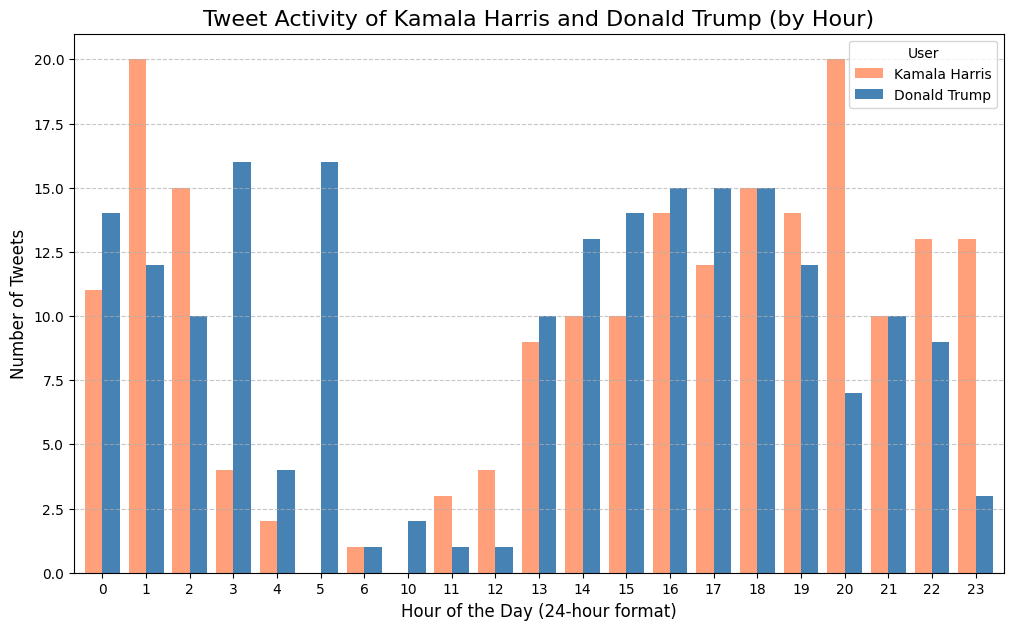

In [10]:

# Convert 'created_at' to datetime format
df['created_at'] = pd.to_datetime(df['created_at'])

# Extract the hour from 'created_at'
df['hour'] = df['created_at'].dt.hour

# Separate the data for each user
# Creating the mini dataframes 
kamala_df = df[df['author'] == 'Kamala Harris']
trump_df = df[df['author'] == 'Donald Trump']

# Group by hour and count the number of tweets for each user
kamala_hours = kamala_df.groupby('hour').size()
trump_hours = trump_df.groupby('hour').size()

# Create a DataFrame for both users' tweet counts by hour
hourly_tweets = pd.DataFrame({
    'Kamala Harris': kamala_hours,
    'Donald Trump': trump_hours
}).fillna(0)

# Plotting the bar chart with custom colors and settings
ax = hourly_tweets.plot(kind='bar', figsize=(12, 7), width=0.8, color=['#FFA07A', '#4682B4'])

# Customizing the plot
plt.title('Tweet Activity of Kamala Harris and Donald Trump (by Hour)', fontsize=16)
plt.xlabel('Hour of the Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='User', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


## Task 3
## Proportion of tweets containing media keys
- Using Pandas, construct a bar chart that shows the proportions of tweets for each user that contain media keys.
- The x-axis should represent the users, and the y-axis should represent the proportions of tweets.
- **[2 marks]**

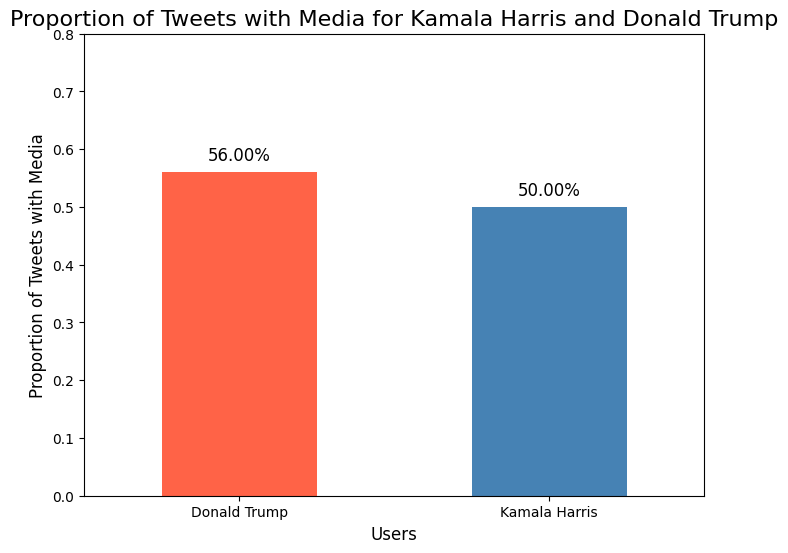

In [5]:

# Check if media_keys exist in the 'attachments' field
df['has_media'] = df['attachments'].apply(lambda x: 'media_keys' in x if isinstance(x, dict) else False)

# Calculate the proportion of tweets with media keys for each user
media_proportions = df.groupby('author')['has_media'].mean()

# Plotting the bar chart
ax = media_proportions.plot(kind='bar', figsize=(8, 6), color=['#FF6347', '#4682B4'], width=0.5)

# Add annotations (percentages) on top of the bars
for i, v in enumerate(media_proportions):
    ax.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', fontsize=12)

# Customize the plot
plt.title('Proportion of Tweets with Media for Kamala Harris and Donald Trump', fontsize=16)
plt.xlabel('Users', fontsize=12)
plt.ylabel('Proportion of Tweets with Media', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 0.8)


# Show the plot
plt.show()


## Task 4
## Histogram of hashtags in tweets
- Construct a histogram using Pandas to display the number of hashtags in tweets for both users.
- The x-axis should represent the number of hashtags, and the y-axis should represent the frequency of tweets.
- **[2 marks]**

## Using entities:

### This method relies on the structured data provided in the tweets.
### It’s more reliable because it directly accesses the parsed hashtags from the tweet data, ensuring that you capture all hashtags consistently.



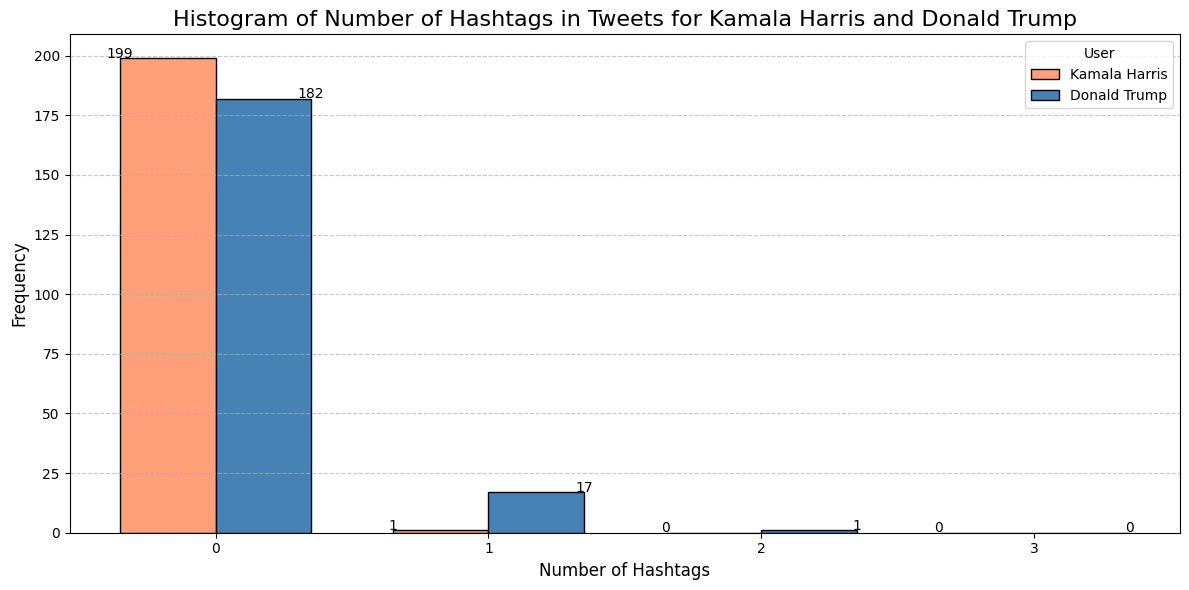

In [31]:


df['num_hashtags'] = df['hashtags'].apply(lambda x: len(x))

# Separate data for each user
kamala_df = df[df['author'] == 'Kamala Harris']
trump_df = df[df['author'] == 'Donald Trump']

# Define bins to include only 0, 1, 2, and 3 hashtags
bins = [0, 1, 2, 3, 4]  # Limiting bins up to 3 (3 is included, but we'll stop showing from 4)

# Plotting side-by-side histograms
plt.figure(figsize=(12, 6))

# Compute histogram values without plotting to get counts
kamala_counts, _ = np.histogram(kamala_df['num_hashtags'], bins=bins)
trump_counts, _ = np.histogram(trump_df['num_hashtags'], bins=bins)

# Setting positions for side-by-side bars
bar_width = 0.35  # Width of bars
bin_centers = np.array(bins[:-1]) + bar_width  # Shift center of bars

# Plotting Kamala Harris's histogram
plt.bar(bin_centers - bar_width/2, kamala_counts, width=bar_width, label='Kamala Harris', color='#FFA07A', edgecolor='black')

# Plotting Donald Trump's histogram
plt.bar(bin_centers + bar_width/2, trump_counts, width=bar_width, label='Donald Trump', color='#4682B4', edgecolor='black')

# Annotating the bars with counts
for i in range(len(kamala_counts)):
    plt.text(bin_centers[i] - bar_width, kamala_counts[i] + 0.1, str(kamala_counts[i]), ha='center', fontsize=10)
    plt.text(bin_centers[i] + bar_width, trump_counts[i] + 0.1, str(trump_counts[i]), ha='center', fontsize=10)

# Customizing the plot
plt.title('Histogram of Number of Hashtags in Tweets for Kamala Harris and Donald Trump', fontsize=16)
plt.xlabel('Number of Hashtags', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(bin_centers, ['0', '1', '2', '3'])  # Show only 0, 1, 2, and 3 on x-axis
plt.legend(title='User')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


## Task 5
## Log-odds ratio of words used in tweets
- Calculate the log odds ratio for each word used in both users' tweets.
- List the 20 words most strongly associated with each user.
- **[3 marks]**

In [49]:

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Assuming df is your DataFrame with tweets

# Step 1: Prepare stopwords

stop_words = set(stopwords.words('english'))

# Step 2: Tokenize the tweets and remove stopwords
def tokenize_and_filter(text):
    words = word_tokenize(text.lower())
    return [word for word in words if word.isalpha() and word not in stop_words]

df['tokens'] = df['text'].apply(tokenize_and_filter)

# Step 3: Create a DataFrame with words and their counts for each user
kamala_words = df[df['author'] == 'Kamala Harris']['tokens'].explode()
trump_words = df[df['author'] == 'Donald Trump']['tokens'].explode()

kamala_counts = kamala_words.value_counts().reset_index()
trump_counts = trump_words.value_counts().reset_index()

kamala_counts.columns = ['word', 'kamala_count']
trump_counts.columns = ['word', 'trump_count']

# Step 4: Merge counts and calculate log odds ratio
word_counts = pd.merge(kamala_counts, trump_counts, on='word', how='outer').fillna(0)
word_counts['kamala_count'] = word_counts['kamala_count'].astype(int)
word_counts['trump_count'] = word_counts['trump_count'].astype(int)

# Step 5: Calculate the log odds ratio
word_counts['total_kamala'] = word_counts['kamala_count'].sum()
word_counts['total_trump'] = word_counts['trump_count'].sum()

word_counts['log_odds'] = np.log((word_counts['kamala_count'] + 1) / (word_counts['total_kamala'] - word_counts['kamala_count'] + 1) /
                                  (word_counts['trump_count'] + 1) / (word_counts['total_trump'] - word_counts['trump_count'] + 1))

# Step 6: Get the top 20 words for each user
top_kamala = word_counts.nlargest(20, 'log_odds')[['word', 'log_odds']]
top_trump = word_counts.nsmallest(20, 'log_odds')[['word', 'log_odds']]

# Displaying Kamala Harris's top 20 words nicely
print("Top 20 Words Associated with Donald Trump:")
print(top_trump.to_string(index= False))


Top 20 Words Associated with Donald Trump:
        word   log_odds
      kamala -19.061407
      harris -18.459507
     comrade -18.349402
         amp -17.822686
   democrats -17.600657
    corporal -17.467683
     eastern -17.467683
     process -17.467683
        book -17.314089
      father -17.314089
   kloeffler -17.314089
     numbers -17.314089
     ballots -17.132323
    elonmusk -17.132323
 enforcement -17.132323
       happy -17.132323
     illegal -17.132323
 importantly -17.132323
       lance -17.132323
legislatures -17.132323


In [51]:
# Displaying Kamala Harris's top 20 words nicely
print("Top 20 Words Associated with Kamala Harris:")
print(top_kamala.to_string(index= False))


Top 20 Words Associated with Kamala Harris:
        word   log_odds
    abortion -12.114410
     freedom -12.474043
    national -12.812482
reproductive -12.812482
        sign -12.812482
         ban -12.881803
      donald -12.884639
  businesses -12.956238
     project -13.036608
      voters -13.036608
        bans -13.123946
      always -13.219584
    business -13.219584
       class -13.219584
      access -13.325271
          ad -13.325271
        bill -13.325271
         roe -13.325271
        work -13.379256
   decisions -13.443381


## Task 6
## Sentiment analysis using Vader
- Use the `vaderSentiment` module to calculate the sentiment of each tweet.
- For each user, compute the average 'compound' sentiment score for all their tweets.
- You can install the vaderSentiment module using `!pip install vaderSentiment`.
- **[2 marks]**


In [52]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to calculate compound sentiment score
def get_compound_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

# Apply the sentiment analysis to each tweet
df['compound_sentiment'] = df['text'].apply(get_compound_sentiment)

# Calculate average compound sentiment for each user
kamala_avg_sentiment = df[df['author'] == 'Kamala Harris']['compound_sentiment'].mean()
trump_avg_sentiment = df[df['author'] == 'Donald Trump']['compound_sentiment'].mean()

# Print the results
print(f"Average Compound Sentiment for Kamala Harris: {kamala_avg_sentiment}")
print(f"Average Compound Sentiment for Donald Trump: {trump_avg_sentiment}")


Average Compound Sentiment for Kamala Harris: 0.2492325
Average Compound Sentiment for Donald Trump: 0.0813715
